In [1]:
import os
import ast
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

SEED = 42 

# 1. Busca automaticamente os arquivos dentro do diretório de inputs do Kaggle
caminho_best = None
caminho_labeled = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'best_combination_per_organ.csv':
            caminho_best = os.path.join(dirname, filename)
        if filename == 'labeled_features_full.csv':
            caminho_labeled = os.path.join(dirname, filename)

if not caminho_best or not caminho_labeled:
    raise FileNotFoundError("Arquivos não encontrados! Confirme se você executou o passo 'Add Input' no painel lateral do Kaggle incluindo o notebook do Marco 3.")

# 2. Carrega os dados usando os caminhos encontrados
best_df = pd.read_csv(caminho_best)
labeled_df_err = pd.read_csv(caminho_labeled)

# 3. Mapeia os descritores
feature_sets_err = {
    "intensidade": [c for c in labeled_df_err.columns if c.startswith("intensity_")],
    "textura": [c for c in labeled_df_err.columns if c.startswith("glcm_")],
    "forma": [c for c in labeled_df_err.columns if c.startswith("shape_")],
}
feature_sets_err["combinado"] = (
    feature_sets_err["intensidade"] + feature_sets_err["textura"] + feature_sets_err["forma"]
)

erro_rows = []
matrizes = {}

# 4. Recria, treina rapidamente e avalia o melhor modelo de cada órgão
for _, row in best_df.iterrows():
    organ = row["orgao"]
    descritor = row["descritor"]
    modelo = row["modelo"]
    hiperparametros = ast.literal_eval(row["melhores_hiperparametros"])
    label_col = f"{organ}_label"
    cols = feature_sets_err[descritor]

    train_mask = labeled_df_err["split"] == "train"
    test_mask = labeled_df_err["split"] == "test"
    
    X_train, y_train = labeled_df_err.loc[train_mask, cols], labeled_df_err.loc[train_mask, label_col]
    X_test, y_test = labeled_df_err.loc[test_mask, cols], labeled_df_err.loc[test_mask, label_col]
    pid_test = labeled_df_err.loc[test_mask, "patient_id"]

    # Recria exatamente o modelo vencedor
    if modelo == "SVM":
        params = {k.replace("svm__", ""): v for k, v in hiperparametros.items()}
        clf = SVC(class_weight="balanced", probability=True, random_state=SEED, **params)
        pipeline = Pipeline([("scaler", StandardScaler()), ("svm", clf)])
        pipeline.fit(X_train, y_train)
        
    elif modelo == "RandomForest":
        params = {k.replace("rf__", ""): v for k, v in hiperparametros.items()}
        clf = RandomForestClassifier(class_weight="balanced_subsample", random_state=SEED, **params)
        pipeline = Pipeline([("scaler", StandardScaler()), ("rf", clf)])
        pipeline.fit(X_train, y_train, rf__sample_weight=compute_sample_weight("balanced", y_train))
        
    else:  # XGBoost
        params = {k.replace("xgb__", ""): v for k, v in hiperparametros.items()}
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train)
        clf = XGBClassifier(random_state=SEED, eval_metric="mlogloss", n_jobs=1, **params)
        pipeline = Pipeline([("scaler", StandardScaler()), ("xgb", clf)])
        pipeline.fit(X_train, y_train_enc, xgb__sample_weight=compute_sample_weight("balanced", y_train_enc))

    # 5. Faz predições no conjunto de teste
    y_pred = pipeline.predict(X_test)
    if modelo == "XGBoost":
        y_pred = le.inverse_transform(y_pred)

    # 6. Gera a Matriz de Confusão
    classes_organ = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=classes_organ)
    matrizes[organ] = pd.DataFrame(cm, index=classes_organ, columns=classes_organ)

    # Salva acertos e erros por paciente
    for pid, yt, yp in zip(pid_test, y_test, y_pred):
        erro_rows.append({
            "orgao": organ, "patient_id": pid, "classe_real": yt,
            "classe_prevista": yp, "acerto": yt == yp,
        })

# Exporta os erros para facilitar a análise qualitativa do artigo
erros_df = pd.DataFrame(erro_rows)
erros_df.to_csv("predicoes_por_paciente.csv", index=False)

# Imprime as matrizes no console
for organ, cm_df in matrizes.items():
    print(f"\n=== Matriz de confusão — {organ} ===")
    print(cm_df)


=== Matriz de confusão — bowel ===
               bowel_healthy  bowel_injury
bowel_healthy             69            29
bowel_injury               2             0

=== Matriz de confusão — extravasation ===
                       extravasation_healthy  extravasation_injury
extravasation_healthy                     59                    31
extravasation_injury                       7                     3

=== Matriz de confusão — kidney ===
                kidney_healthy  kidney_high  kidney_low
kidney_healthy              56           20          19
kidney_high                  1            3           0
kidney_low                   0            0           1

=== Matriz de confusão — liver ===
               liver_healthy  liver_high  liver_low
liver_healthy             56           2         32
liver_high                 1           0          0
liver_low                  5           0          4

=== Matriz de confusão — spleen ===
                spleen_healthy  spleen_high  spl

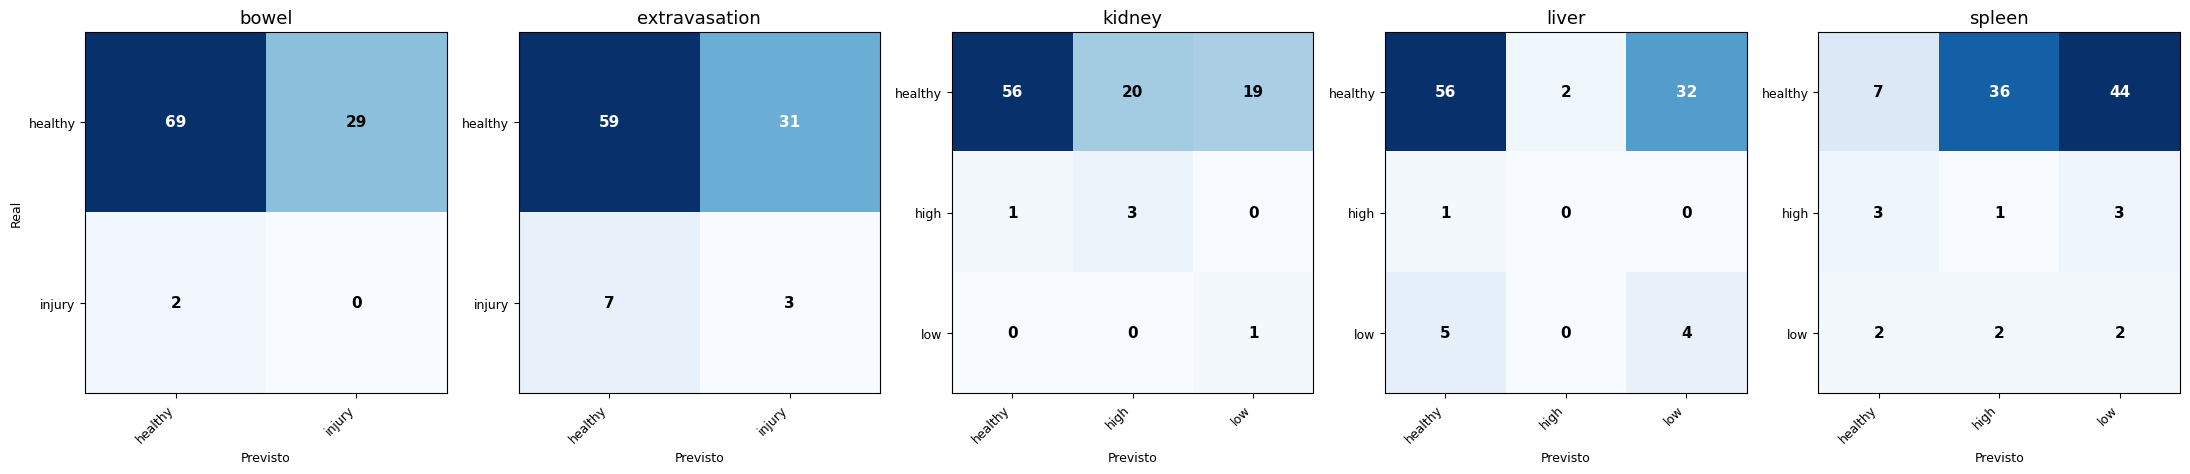

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for ax, (organ, cm_df) in zip(axes, matrizes.items()):
    im = ax.imshow(cm_df.values, cmap="Blues")
    ax.set_title(organ, fontsize=13)

    # Rótulos dos eixos (encurtando "spleen_healthy" -> "healthy", etc.)
    labels_curtos = [c.split("_", 1)[1] if "_" in c else c for c in cm_df.columns]
    ax.set_xticks(range(len(labels_curtos)))
    ax.set_yticks(range(len(labels_curtos)))
    ax.set_xticklabels(labels_curtos, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(labels_curtos, fontsize=9)
    ax.set_xlabel("Previsto", fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("Real", fontsize=9)

    # Escreve o valor de cada célula em cima do quadrado
    vmax = cm_df.values.max()
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            valor = cm_df.values[i, j]
            cor_texto = "white" if valor > vmax / 2 else "black"
            ax.text(j, i, str(valor), ha="center", va="center",
                     color=cor_texto, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()